In [2]:
!pip install textblob seaborn

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for seaborn plots
sns.set_theme(style="whitegrid")

# Load the Titanic dataset from an online repository
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display the first 5 rows of the dataset to verify it loaded correctly
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Check the shape of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape}\n")

# Get a concise summary of the dataframe, including data types and non-null counts
print("Dataframe Information:")
print(df.info())

# Count the number of missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Dataframe Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket    

In [7]:
# 1. Fill missing 'Age' values with the median age (robust to outliers)
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

# 2. Fill missing 'Embarked' values with the mode (most frequent value)
most_frequent_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(most_frequent_embarked, inplace=True)

# 3. 'Cabin' has too many missing values (>75%), so we will drop the column
df.drop(columns=['Cabin'], inplace=True)

# Verify that there are no more missing values (except Cabin which is gone)
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_5194/3127856549.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)
/tmp/ipykernel_5194/3127856549.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [8]:
# Descriptive statistics for numerical columns
print("Summary statistics for numerical features:")
display(df.describe())

# Descriptive statistics for categorical columns
print("\nSummary statistics for categorical features:")
display(df.describe(include=['O']))

Summary statistics for numerical features:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Summary statistics for categorical features:


,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Dooley, Mr. Patrick",male,347082,S
freq,1,577,7,646


/tmp/ipykernel_5194/2954199997.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set1')
/tmp/ipykernel_5194/2954199997.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])
/tmp/ipykernel_5194/2954199997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', ax=axes[1], palette='Set2')


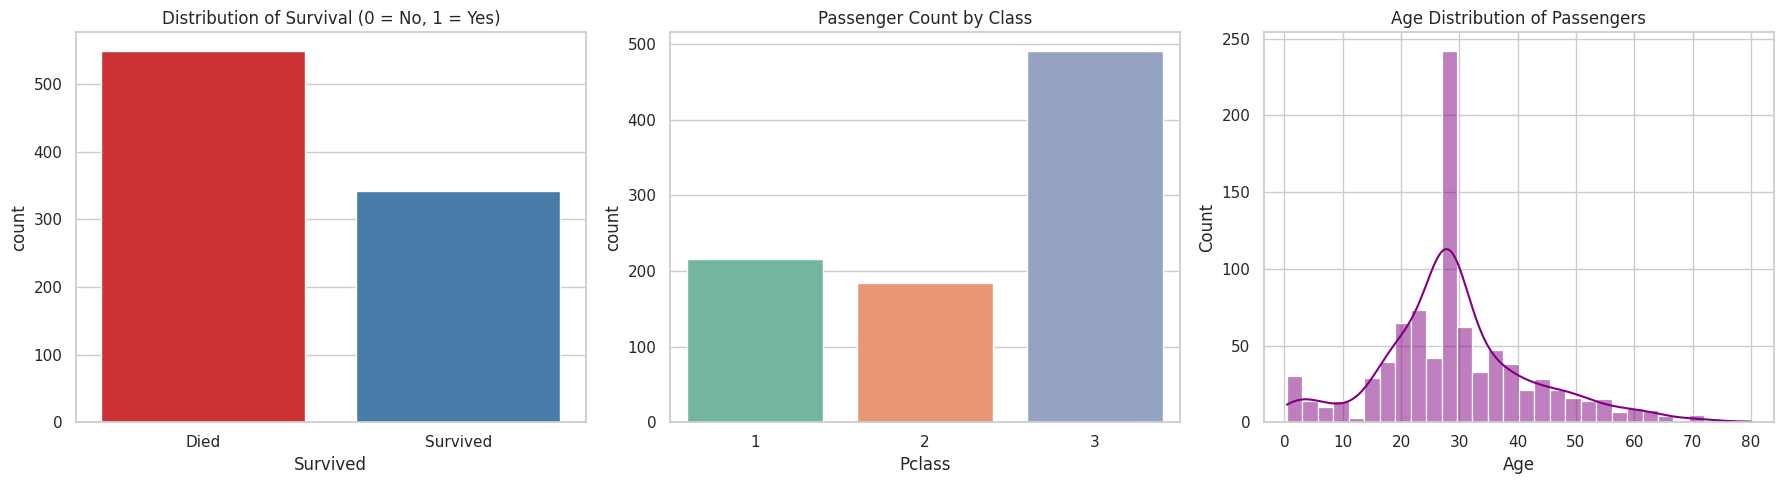

In [9]:
# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Survival Count
sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set1')
axes[0].set_title('Distribution of Survival (0 = No, 1 = Yes)')
axes[0].set_xticklabels(['Died', 'Survived'])

# Plot 2: Passenger Class Count
sns.countplot(data=df, x='Pclass', ax=axes[1], palette='Set2')
axes[1].set_title('Passenger Count by Class')

# Plot 3: Age Distribution
sns.histplot(data=df, x='Age', bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Age Distribution of Passengers')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5194/3408978903.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], ci=None, palette='pastel')
/tmp/ipykernel_5194/3408978903.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], ci=None, palette='pastel')
/tmp/ipykernel_5194/3408978903.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', ax=axes[1], ci=None, palette='muted')


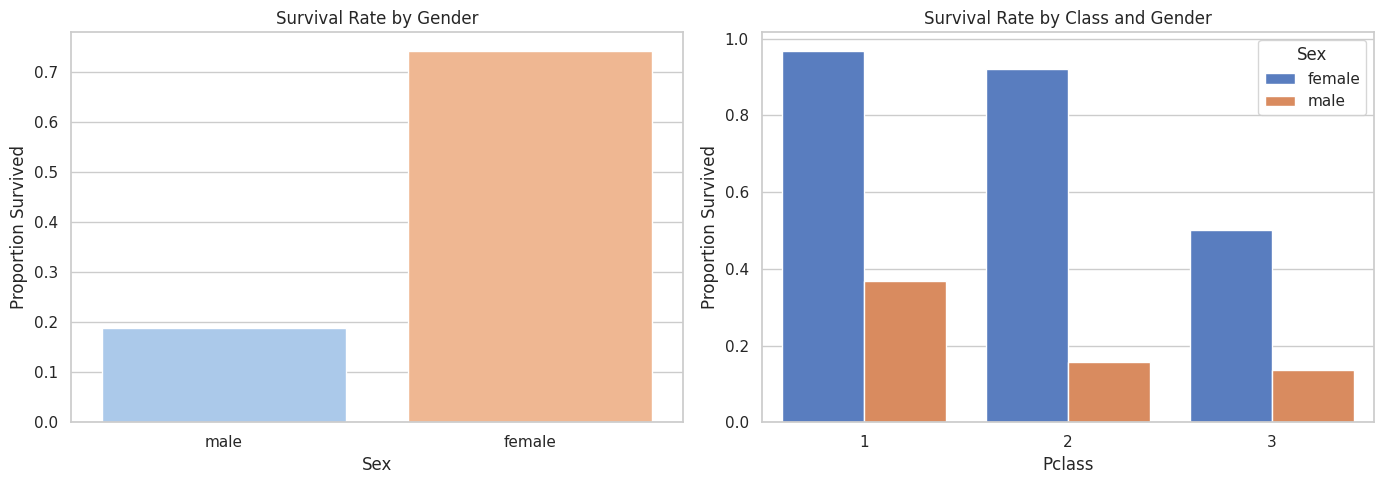

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Survival Rate by Gender
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], ci=None, palette='pastel')
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Proportion Survived')

# Plot 2: Survival Rate by Passenger Class and Gender
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', ax=axes[1], ci=None, palette='muted')
axes[1].set_title('Survival Rate by Class and Gender')
axes[1].set_ylabel('Proportion Survived')

plt.tight_layout()
plt.show()

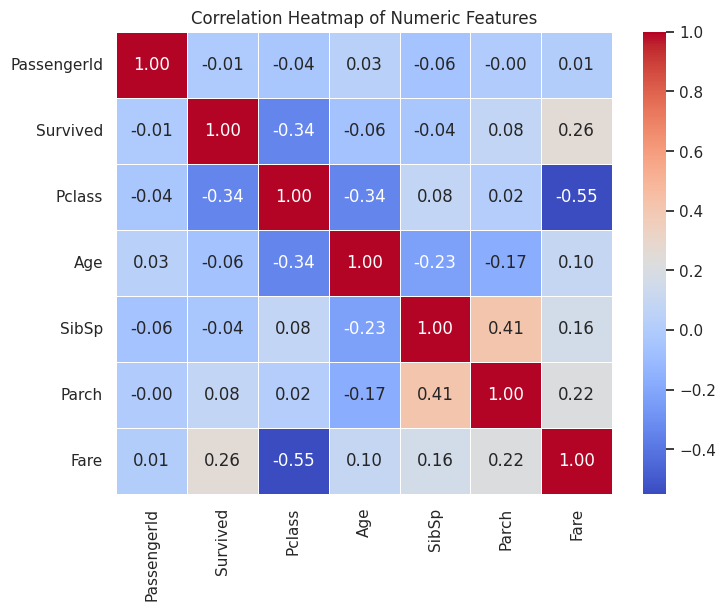

In [11]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numerical_cols.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()